In [1]:
import os
os.chdir(r"D:\Git_repos\tabnet")

In [3]:
from pytorch_tabnet.tab_model import TabNetClassifier

import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
np.random.seed(0)

import os
import wget
from pathlib import Path
import shutil
import gzip

from matplotlib import pyplot as plt
%matplotlib inline

#### Download ForestCoverType dataset

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"
dataset_name = 'forest-cover-type'
tmp_out = Path('./data/'+dataset_name+'.gz')
out = Path(os.getcwd()+'/data/'+dataset_name+'.csv')

In [5]:
out.parent.mkdir(parents=True, exist_ok=True)
if out.exists():
    print("File already exists.")
else:
    print("Downloading file...")
    wget.download(url, tmp_out.as_posix())
    with gzip.open(tmp_out, 'rb') as f_in:
        with open(out, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

File already exists.


#### Load data and split
Same split as in original paper

In [6]:
target = "Covertype"

bool_columns = [
    "Wilderness_Area1", "Wilderness_Area2", "Wilderness_Area3",
    "Wilderness_Area4", "Soil_Type1", "Soil_Type2", "Soil_Type3", "Soil_Type4",
    "Soil_Type5", "Soil_Type6", "Soil_Type7", "Soil_Type8", "Soil_Type9",
    "Soil_Type10", "Soil_Type11", "Soil_Type12", "Soil_Type13", "Soil_Type14",
    "Soil_Type15", "Soil_Type16", "Soil_Type17", "Soil_Type18", "Soil_Type19",
    "Soil_Type20", "Soil_Type21", "Soil_Type22", "Soil_Type23", "Soil_Type24",
    "Soil_Type25", "Soil_Type26", "Soil_Type27", "Soil_Type28", "Soil_Type29",
    "Soil_Type30", "Soil_Type31", "Soil_Type32", "Soil_Type33", "Soil_Type34",
    "Soil_Type35", "Soil_Type36", "Soil_Type37", "Soil_Type38", "Soil_Type39",
    "Soil_Type40"
]

int_columns = [
    "Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology", "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

feature_columns = (
    int_columns + bool_columns + [target])


In [ ]:
train = pd.read_csv(out, header=None, names=feature_columns)

n_total = len(train)

# Train, val and test split follows
# Rory Mitchell, Andrey Adinets, Thejaswi Rao, and Eibe Frank.
# Xgboost: Scalable GPU accelerated learning. arXiv:1806.11248, 2018.

# train_data: 0.8 - (0.8 / 3) =  0.54
# val_data:   0.8 / 3 =          0.26 
# test_data: 0.2 =               0.2

train_val_indices, test_indices = train_test_split(
    range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices = train_test_split(
    train_val_indices, test_size=0.2 / 0.6, random_state=0)


In [18]:
print(len(train_indices))
print(len(valid_indices))
print(len(test_indices))

total = len(train_indices) + len(valid_indices) + len(test_indices)

print(len(train_indices)/total)
print(len(valid_indices)/total)
print(len(test_indices)/total)

309872
154937
116203
0.5333314974561627
0.26666746986292883
0.2000010326809085


In [13]:
train

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Covertype
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,...,0,0,0,0,0,0,0,0,0,3
581008,2391,152,19,67,12,95,240,237,119,845,...,0,0,0,0,0,0,0,0,0,3
581009,2386,159,17,60,7,90,236,241,130,854,...,0,0,0,0,0,0,0,0,0,3
581010,2384,170,15,60,5,90,230,245,143,864,...,0,0,0,0,0,0,0,0,0,3


#### Simple preprocessing

Label encode categorical features and fill empty cells.

In [20]:
categorical_columns = []
categorical_dims =  {}
for col in train.columns[train.dtypes == object]:
    print(col, train[col].nunique())
    l_enc = LabelEncoder()
    train[col] = train[col].fillna("VV_likely")
    train[col] = l_enc.fit_transform(train[col].values)
    categorical_columns.append(col)
    categorical_dims[col] = len(l_enc.classes_)

for col in train.columns[train.dtypes == 'float64']:
    train.fillna(train.loc[train_indices, col].mean(), inplace=True)

#### Define categorical features for categorical embeddings

In [21]:
# This is a generic pipeline but actually no categorical features are available for this dataset

unused_feat = []

features = [ col for col in train.columns if col not in unused_feat+[target]] 

cat_idxs = [ i for i, f in enumerate(features) if f in categorical_columns]

cat_dims = [ categorical_dims[f] for i, f in enumerate(features) if f in categorical_columns]


#### Network parameters

In [22]:
clf = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=1,
    lambda_sparse=1e-4, momentum=0.3, clip_value=2.,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params = {"gamma": 0.95,
                     "step_size": 20},
    scheduler_fn=torch.optim.lr_scheduler.StepLR, epsilon=1e-15
)

D:\Git_repos\tabnet\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


#### Training

In [23]:
if os.getenv("CI", False):
# Take only a subsample to run CI
    X_train = train[features].values[train_indices][:1000,:]
    y_train = train[target].values[train_indices][:1000]
else:
    X_train = train[features].values[train_indices]
    y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

In [24]:
max_epochs = 100 if not os.getenv("CI", False) else 2

In [25]:
from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    max_epochs=max_epochs, patience=100,
    batch_size=16384, virtual_batch_size=256,
    augmentations=aug
) 

epoch 0  | loss: 1.20994 | train_accuracy: 0.26837 | valid_accuracy: 0.26924 |  0:00:20s
epoch 1  | loss: 0.75948 | train_accuracy: 0.03797 | valid_accuracy: 0.03779 |  0:00:36s
epoch 2  | loss: 0.71546 | train_accuracy: 0.03773 | valid_accuracy: 0.03762 |  0:00:51s
epoch 3  | loss: 0.69663 | train_accuracy: 0.04105 | valid_accuracy: 0.04095 |  0:01:07s
epoch 4  | loss: 0.68236 | train_accuracy: 0.0471  | valid_accuracy: 0.0475  |  0:01:22s
epoch 5  | loss: 0.66797 | train_accuracy: 0.06228 | valid_accuracy: 0.06228 |  0:01:38s
epoch 6  | loss: 0.66308 | train_accuracy: 0.05419 | valid_accuracy: 0.05398 |  0:01:54s
epoch 7  | loss: 0.64893 | train_accuracy: 0.08113 | valid_accuracy: 0.08163 |  0:02:10s
epoch 8  | loss: 0.63579 | train_accuracy: 0.15091 | valid_accuracy: 0.15034 |  0:02:27s
epoch 9  | loss: 0.61757 | train_accuracy: 0.17898 | valid_accuracy: 0.17863 |  0:02:42s
epoch 10 | loss: 0.60717 | train_accuracy: 0.30241 | valid_accuracy: 0.30188 |  0:02:58s
epoch 11 | loss: 0.60

D:\Git_repos\tabnet\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


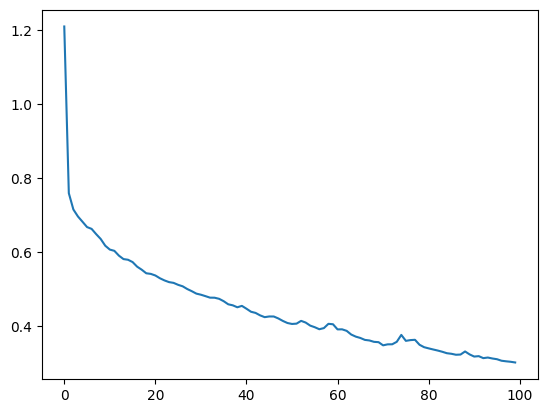

In [26]:
# plot losses
plt.plot(clf.history['loss'])

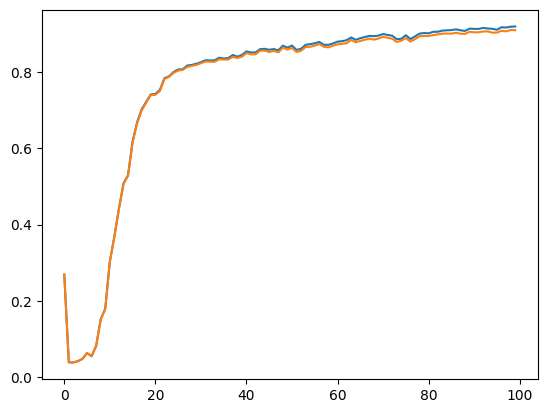

In [27]:
# plot accuracy
plt.plot(clf.history['train_accuracy'])
plt.plot(clf.history['valid_accuracy'])

### Predictions


In [28]:
# To get final results you may need to use a mapping for classes 
# as you are allowed to use targets like ["yes", "no", "maybe", "I don't know"]

preds_mapper = { idx : class_name for idx, class_name in enumerate(clf.classes_)}

preds = clf.predict_proba(X_test)

y_pred = np.vectorize(preds_mapper.get)(np.argmax(preds, axis=1))

test_acc = accuracy_score(y_pred=y_pred, y_true=y_test)

print(f"BEST VALID SCORE FOR {dataset_name} : {clf.best_cost}")
print(f"FINAL TEST SCORE FOR {dataset_name} : {test_acc}")

BEST VALID SCORE FOR forest-cover-type : 0.9112542517281218
FINAL TEST SCORE FOR forest-cover-type : 0.9117148438508472


In [29]:
# or you can simply use the predict method

y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_pred=y_pred, y_true=y_test)
print(f"FINAL TEST SCORE FOR {dataset_name} : {test_acc}")

FINAL TEST SCORE FOR forest-cover-type : 0.9117148438508472


# Save and load Model

In [30]:
# save state dict
saved_filename = clf.save_model('test_model')

Successfully saved model at test_model.zip


In [31]:
# define new model and load save parameters
loaded_clf = TabNetClassifier()
loaded_clf.load_model(saved_filename)

D:\Git_repos\tabnet\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [32]:
loaded_preds = loaded_clf.predict_proba(X_test)
loaded_y_pred = np.vectorize(preds_mapper.get)(np.argmax(loaded_preds, axis=1))

loaded_test_acc = accuracy_score(y_pred=loaded_y_pred, y_true=y_test)

print(f"FINAL TEST SCORE FOR {dataset_name} : {loaded_test_acc}")

FINAL TEST SCORE FOR forest-cover-type : 0.9117148438508472


In [33]:
assert(test_acc == loaded_test_acc)

# Global explainability : feat importance summing to 1

In [34]:
clf.feature_importances_

array([1.14712234e-01, 5.99839896e-03, 2.94287768e-03, 1.57530224e-02,
       6.22016910e-02, 6.77906604e-02, 3.61801142e-03, 4.78433430e-02,
       5.21195660e-02, 8.73886120e-02, 3.38678057e-03, 1.45969592e-02,
       5.32692039e-02, 4.37077879e-03, 6.87571075e-04, 5.77820599e-03,
       1.67995946e-02, 1.43221812e-02, 9.97207278e-03, 3.00895510e-02,
       7.48652700e-03, 6.53049853e-03, 1.52158299e-03, 6.64393366e-05,
       2.21507050e-04, 4.42861818e-02, 1.45351883e-03, 1.05112202e-02,
       6.86989982e-03, 1.29071634e-02, 1.02839550e-04, 2.85830812e-03,
       6.62604398e-04, 1.81547811e-03, 3.89086034e-03, 4.30176894e-03,
       4.41245561e-02, 3.32174465e-04, 4.99259022e-03, 6.37622529e-03,
       1.15802256e-04, 1.07119959e-02, 1.86471672e-02, 2.58126710e-02,
       4.38885891e-02, 2.74494082e-02, 3.31864291e-02, 3.00408506e-03,
       1.58866535e-02, 1.77592685e-02, 9.77107211e-03, 5.46105966e-03,
       6.95700248e-03, 6.39553544e-03])

# Local explainability and masks

In [35]:
explain_matrix, masks = clf.explain(X_test)

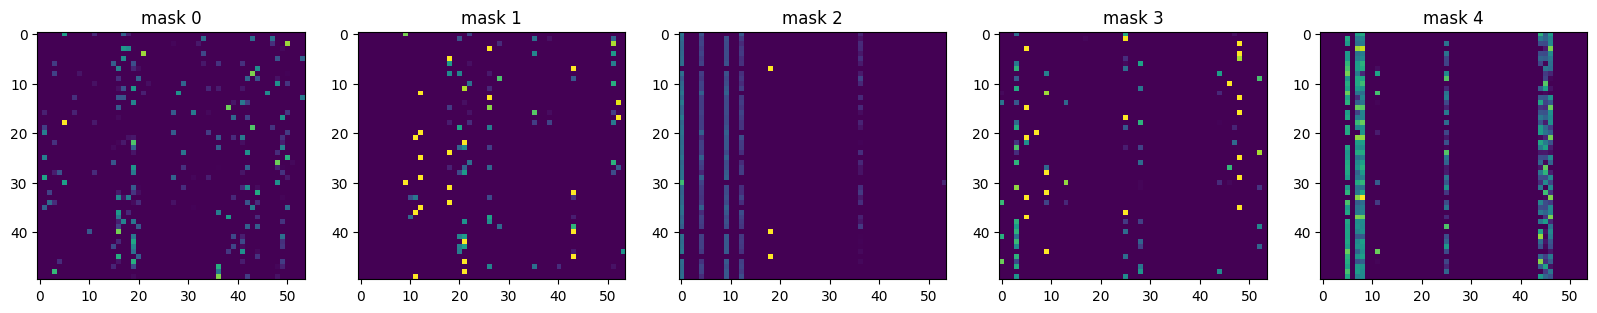

In [36]:
fig, axs = plt.subplots(1, 5, figsize=(20,20))

for i in range(5):
    axs[i].imshow(masks[i][:50])
    axs[i].set_title(f"mask {i}")

# XGB

In [37]:
n_estimators = 1000 if not os.getenv("CI", False) else 20

In [38]:
from xgboost import XGBClassifier

clf_xgb = XGBClassifier(max_depth=8,
    learning_rate=0.1,
    n_estimators=n_estimators,
    verbosity=0,
    silent=None,
    objective="multi:softmax",
    booster='gbtree',
    n_jobs=-1,
    nthread=None,
    gamma=0,
    min_child_weight=1,
    max_delta_step=0,
    subsample=0.7,
    colsample_bytree=1,
    colsample_bylevel=1,
    colsample_bynode=1,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    base_score=0.5,
    random_state=0,
    seed=None,)

clf_xgb.fit(X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            early_stopping_rounds=40,
            verbose=10)

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
preds_valid = np.array(clf_xgb.predict_proba(X_valid, ))
valid_acc = accuracy_score(y_pred=np.argmax(preds_valid, axis=1) + 1, y_true=y_valid)
print(valid_acc)

preds_test = np.array(clf_xgb.predict_proba(X_test))
test_acc = accuracy_score(y_pred=np.argmax(preds_test, axis=1) + 1, y_true=y_test)
print(test_acc)